In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200 # 200 houses
n_features = 5 # 5 features per house

# true weights to be discovered by the model
w_true = np.array([3.0, -2.0, 0.5, 1.5, -1.0])
b_true = 7.0

X = np.random.randn(n, n_features) # shape (200, 5)

# true prices
y = X @ w_true + b_true + np.random.randn(n) * 0.5 # shape (200,)

print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")
print(f"First house features: {X[0]}")
print(f"First house price: {y[0]:.2f}")

y shape: (200,)
X shape: (200, 5)
First house features: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
First house price: 12.31


In [5]:
def predict(X, w, b):
    return X @ w + b

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

w = np.random.randn(n_features) * 0.01
b = 0.0

print(f"Initial loss: {mse_loss(y, predict(X, w, b)):.2f}")

Initial loss: 66.70


In [10]:
y_pred = X @ w + b
error = y_pred - y

dw_a = (2 / n) * (X.T @ error) # (5,) - one gradient per weight
db_a = (2 / n) * np.sum(error) # scalar - one gradient for bias

In [13]:
def numerical_gradients(X, w, b, y, param='w', idx=0, eps=1e-5):
    if param == 'w':
        w_plus = w.copy();
        w_plus[idx] += eps
        w_minus = w.copy();
        w_minus[idx] -= eps
        loss_plus = np.mean((X @ w_plus + b - y) ** 2)
        loss_minus = np.mean((X @ w_minus + b - y) ** 2)
    else:
        loss_plus = np.mean((X @ w + (b + eps) - y) ** 2)
        loss_minus = np.mean((X @ w + (b - eps) - y) ** 2)
    return (loss_plus - loss_minus) / (2 * eps)

print("Analytical vs Numerical gradients for w:")
for i in range(n_features):
    dw_n = numerical_gradients(X, w, b, y, 'w', idx=i)
    print(f"w[{i}]: analytical:{dw_a[i]:+.6f} vs numerical:{dw_n:+.6f}, match ={np.abs(dw_a[i] - dw_n) < 1e-5}")

db_n = numerical_gradients(X, w, b, y, 'b')
print(f"b: {db_a:.6f} vs {db_n:.6f}, match={np.abs(db_a - db_n) < 1e-5}")


Analytical vs Numerical gradients for w:
w[0]: analytical:-5.273950 vs numerical:-5.273950, match =True
w[1]: analytical:+4.699743 vs numerical:+4.699743, match =True
w[2]: analytical:-0.725619 vs numerical:-0.725619, match =True
w[3]: analytical:-3.851905 vs numerical:-3.851905, match =True
w[4]: analytical:+1.432964 vs numerical:+1.432964, match =True
b: -14.203433 vs -14.203433, match=True


Epoch:    0 Loss: 66.5984 b: 0.1420
Epoch:  100 Loss: 1.4476 b: 6.1381
Epoch:  200 Loss: 0.2858 b: 6.9349
Epoch:  300 Loss: 0.2616 b: 7.0451
Epoch:  400 Loss: 0.2610 b: 7.0611
Epoch:  500 Loss: 0.2610 b: 7.0635
Epoch:  600 Loss: 0.2610 b: 7.0638
Epoch:  700 Loss: 0.2610 b: 7.0639
Epoch:  800 Loss: 0.2610 b: 7.0639
Epoch:  900 Loss: 0.2610 b: 7.0639
Epoch: 1000 Loss: 0.2610 b: 7.0639
Epoch: 1100 Loss: 0.2610 b: 7.0639
Epoch: 1200 Loss: 0.2610 b: 7.0639
Epoch: 1300 Loss: 0.2610 b: 7.0639
Epoch: 1400 Loss: 0.2610 b: 7.0639
Epoch: 1500 Loss: 0.2610 b: 7.0639
Epoch: 1600 Loss: 0.2610 b: 7.0639
Epoch: 1700 Loss: 0.2610 b: 7.0639
Epoch: 1800 Loss: 0.2610 b: 7.0639
Epoch: 1900 Loss: 0.2610 b: 7.0639
Learned w: [ 2.97496502 -1.96644711  0.506478    1.52700706 -0.97921476]
True w: [ 3.  -2.   0.5  1.5 -1. ]
Learned b: 7.0639, b true: 7.0


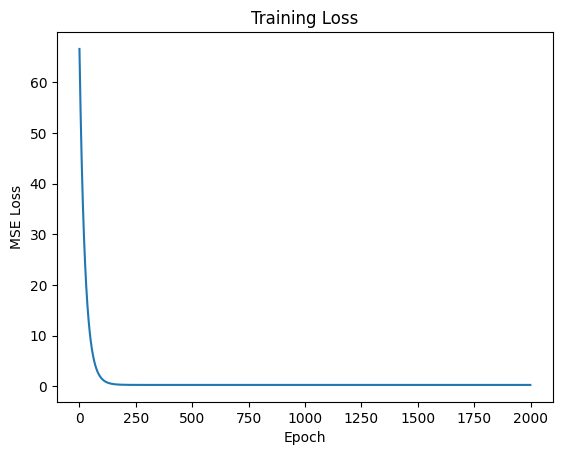

In [19]:
w = np.random.randn(n_features) * 0.01
b = 0.0
lr = 0.01
epochs = 2000
history = []

for epoch in range(epochs):
    y_pred = X @ w + b
    error = y_pred - y
    loss = np.mean(error ** 2)
    history.append(loss)

    dw = (2 / n) * (X.T @ error)
    db = (2/ n) * np.sum(error)
    w -= lr * dw
    b -= lr * db

    if epoch % 100 == 0:
        print(f"Epoch: {epoch:4d} Loss: {loss:.4f} b: {b:.4f}")

print(f"Learned w: {w}")
print(f"True w: {w_true}")
print(f"Learned b: {b:.4f}, b true: {b_true}")

plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()

Converged in epochs: 200 lr = 0.1
Learned bias: 7.1022, b true: 7.0


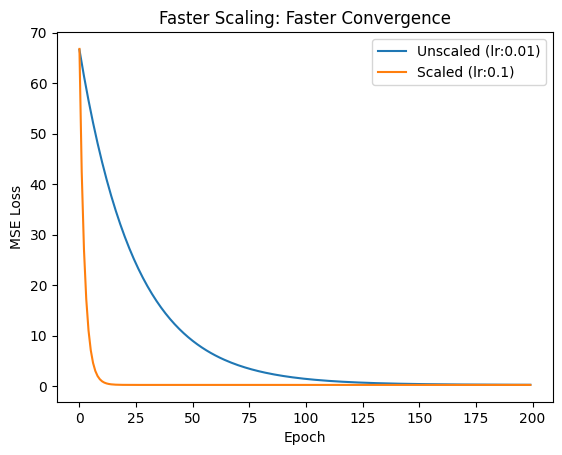

In [21]:
# feature scaling
# for each feature, subtract mean and divide std
def standardize(X):
    mean = np.mean(X, axis=0) # std of each col (5,1) - shape
    std = np.std(X, axis=0) # std of each col (5,1) - shape
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

X_scaled, X_mean, X_std = standardize(X)

w = np.random.randn(n_features) * 0.01
b = 0.0
lr = 0.1
epochs = 200
losses_scaled = []

for epoch in range(epochs):
    y_pred = X_scaled @ w + b
    error = y_pred - y
    loss = np.mean(error ** 2)
    losses_scaled.append(loss)
    dw = ( 2/ n) * X_scaled.T @ error
    db = ( 2 / n) * np.sum(error)
    w -= lr * dw
    b -= lr * db

print(f"Converged in epochs: {epochs} lr = {lr}")
print(f"Learned bias: {b:.4f}, b true: {b_true}")

plt.plot(history[:200], label="Unscaled (lr:0.01)")
plt.plot(losses_scaled[:200], label="Scaled (lr:0.1)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Faster Scaling: Faster Convergence")
plt.legend()
plt.show()

In [22]:
def train_test_split(X,y, test_ratio=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    test_size = int(len(X) * test_ratio)
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
print(f"Train: {X_train.shape}, Test : {X_test.shape}")

Train: (160, 5), Test : (40, 5)


In [23]:
# train on training set
N_train = len(X_train)
w = np.random.randn(n_features) * 0.01
b = 0.0
lr = 0.1

for epoch in range(500):
    y_pred = X_train @ w + b
    error = y_pred - y_train
    dw = (2 / n) * (X_train.T @ error)
    db = (2 / n) * np.sum(error)
    w -= lr * dw
    b -= lr * db

y_test_pred = X_test @ w + b

mse = np.mean((y_test_pred - y_test) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_test_pred))
ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE: {mse:.4f}") # mean squared error
print(f"RMSE: {rmse:.4f}") # root mse
print(f"MAE: {mae:.4f}") # mean absolute error - avg absolute mistake
print(f"R2: {r2:.4f}") # 1.0 = perfect 0.0 = bad

MSE: 0.2295
RMSE: 0.4790
MAE: 0.4111
R2: 0.9802
